# Bước 2 – Tiền Xử Lý Dữ Liệu (Pre-processing)

## Mục tiêu
Dữ liệu thô thường có nhiều, thiếu giá trị và không đồng nhất về quy mô. Bước này chuẩn bị dữ liệu sạch và chuẩn hóa cho mô hình ML.

## Các bước thực hiện:
1. **Xử lý dữ liệu khuyết (Missing Values)** — Forward Fill cho ngày nghỉ lễ, không giao dịch
2. **Chuyển đổi đặc trưng** — Tính % thay đổi giá (daily return) để loại bỏ tính non-stationary
3. **Chia dữ liệu** — Train/Test theo thời gian (TimeSeriesSplit), KHÔNG shuffle
4. **Chuẩn hóa dữ liệu (Scaling)** — MinMaxScaler, fit chỉ trên train, transform trên test
5. **Lưu dữ liệu** — CSV + scaler pickle cho các bước tiếp theo

## Lưu ý quan trọng:
- **Không data leakage**: Scaler chỉ fit trên tập train, sau đó transform trên test
- **Không shuffle**: Dữ liệu chuỗi thời gian phải giữ nguyên thứ tự thời gian

## 2.1. Import thư viện và cấu hình

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# === ĐƯỜNG DẪN ===
RAW_DATA_DIR = os.path.join('..', 'data', 'raw')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Danh sách 5 mã cổ phiếu + dữ liệu bổ sung
STOCK_SYMBOLS = ['VCB', 'FPT', 'HPG', 'VIC', 'POW']
SUPPLEMENT_SYMBOLS = ['VNINDEX', 'USDVND']

print(f"Thư mục dữ liệu thô: {RAW_DATA_DIR}")
print(f"Thư mục dữ liệu xử lý: {PROCESSED_DIR}")

Thư mục dữ liệu thô: ..\data\raw
Thư mục dữ liệu xử lý: ..\data\processed


## 2.2. Tải dữ liệu thô từ Bước 1

Đọc toàn bộ file CSV đã lưu ở `data/raw/` và hiển thị thông tin cơ bản.

In [2]:
# Tải toàn bộ dữ liệu thô
stock_data = {}
all_symbols = STOCK_SYMBOLS + SUPPLEMENT_SYMBOLS

for symbol in all_symbols:
    filepath = os.path.join(RAW_DATA_DIR, f'{symbol}.csv')
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        df['time'] = pd.to_datetime(df['time'])
        df = df.sort_values('time').reset_index(drop=True)
        stock_data[symbol] = df
        print(f"✓ {symbol:8s} | {len(df):>5d} dòng | {df['time'].min().date()} → {df['time'].max().date()} | Null: {df.isnull().sum().sum()}")
    else:
        print(f"✗ {symbol:8s} | File không tồn tại: {filepath}")

print(f"\n→ Đã tải {len(stock_data)} bộ dữ liệu")

✓ VCB      |  1623 dòng | 2019-09-17 → 2026-03-18 | Null: 0
✓ FPT      |  1623 dòng | 2019-09-17 → 2026-03-18 | Null: 0
✓ HPG      |  1623 dòng | 2019-09-17 → 2026-03-18 | Null: 0
✓ VIC      |  1623 dòng | 2019-09-17 → 2026-03-18 | Null: 0
✓ POW      |  1623 dòng | 2019-09-17 → 2026-03-18 | Null: 0
✓ VNINDEX  |  1623 dòng | 2019-09-17 → 2026-03-18 | Null: 0
✓ USDVND   |  1615 dòng | 2020-01-01 → 2026-03-17 | Null: 0

→ Đã tải 7 bộ dữ liệu


## 2.3. Xử lý dữ liệu khuyết (Missing Values)

Dùng phương pháp **Forward Fill** (`ffill`) để điền giá trị cho các ngày nghỉ lễ, ngày không có giao dịch.

**Tại sao dùng Forward Fill?**  
Trong dữ liệu tài chính, giá của ngày nghỉ được coi là giữ nguyên so với phiên giao dịch gần nhất trước đó. Forward Fill lấy giá trị cuối cùng đã biết để điền vào các ô trống — phù hợp với logic thị trường.

**Backward Fill** (`bfill`) được dùng làm fallback cho các dòng đầu tiên (nếu có null).

In [3]:
# Xử lý missing values và báo cáo trước/sau
missing_report = []

for symbol, df in stock_data.items():
    # Đếm missing values TRƯỚC khi xử lý
    missing_before = df.isnull().sum().sum()
    missing_rows_before = df[df.isnull().any(axis=1)].shape[0]
    
    # Áp dụng Forward Fill → Backward Fill (fallback cho dòng đầu)
    df_filled = df.copy()
    df_filled = df_filled.ffill()    # Forward fill
    df_filled = df_filled.bfill()    # Backward fill cho dòng đầu (nếu có)
    
    # Đếm missing values SAU khi xử lý
    missing_after = df_filled.isnull().sum().sum()
    missing_rows_after = df_filled[df_filled.isnull().any(axis=1)].shape[0]
    
    # Cập nhật dữ liệu
    stock_data[symbol] = df_filled
    
    missing_report.append({
        'Mã CP': symbol,
        'Null trước': missing_before,
        'Dòng có null trước': missing_rows_before,
        'Null sau': missing_after,
        'Dòng có null sau': missing_rows_after,
        'Dòng đã điền': missing_rows_before - missing_rows_after
    })

# Hiển thị báo cáo
report_df = pd.DataFrame(missing_report)
print("=" * 80)
print("BÁO CÁO XỬ LÝ DỮ LIỆU KHUYẾT (Forward Fill)")
print("=" * 80)
print(report_df.to_string(index=False))

total_filled = report_df['Dòng đã điền'].sum()
total_null_remaining = report_df['Null sau'].sum()
print(f"\n→ Tổng dòng đã điền: {total_filled}")
print(f"→ Tổng null còn lại: {total_null_remaining}")

if total_null_remaining == 0:
    print("✓ Tất cả missing values đã được xử lý thành công!")
else:
    print("⚠ Vẫn còn missing values cần kiểm tra!")

BÁO CÁO XỬ LÝ DỮ LIỆU KHUYẾT (Forward Fill)
  Mã CP  Null trước  Dòng có null trước  Null sau  Dòng có null sau  Dòng đã điền
    VCB           0                   0         0                 0             0
    FPT           0                   0         0                 0             0
    HPG           0                   0         0                 0             0
    VIC           0                   0         0                 0             0
    POW           0                   0         0                 0             0
VNINDEX           0                   0         0                 0             0
 USDVND           0                   0         0                 0             0

→ Tổng dòng đã điền: 0
→ Tổng null còn lại: 0
✓ Tất cả missing values đã được xử lý thành công!


## 2.4. Chuyển đổi đặc trưng — Tính % thay đổi giá (Daily Return)

Thay vì sử dụng giá tuyệt đối (non-stationary), ta tính **% thay đổi giá hàng ngày** (daily return):

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} \times 100$$

**Tại sao cần chuyển đổi?**
- Giá tuyệt đối có xu hướng tăng/giảm theo thời gian (non-stationary) → mô hình khó học
- Daily return dao động quanh 0, phân phối ổn định hơn (stationary) → mô hình dự báo tốt hơn
- Volume giữ nguyên giá trị gốc vì đã có tính stationary tự nhiên

In [4]:
# Tính daily return cho các cột giá
price_columns = ['open', 'high', 'low', 'close']
returns_data = {}

for symbol, df in stock_data.items():
    df_returns = df.copy()
    
    # Tính % thay đổi giá (pct_change) cho các cột giá
    for col in price_columns:
        if col in df_returns.columns:
            df_returns[f'{col}_return'] = df_returns[col].pct_change()
    
    # Giữ lại: time + return columns + volume
    return_cols = [f'{col}_return' for col in price_columns if col in df.columns]
    keep_cols = ['time'] + return_cols + (['volume'] if 'volume' in df.columns else [])
    df_returns = df_returns[keep_cols]
    
    # Xóa dòng đầu tiên (NaN từ pct_change)
    df_returns = df_returns.iloc[1:].reset_index(drop=True)
    
    returns_data[symbol] = df_returns
    
    print(f"\n{'='*60}")
    print(f"{symbol} — Daily Returns")
    print(f"{'='*60}")
    print(f"Shape: {df_returns.shape}")
    print(f"\n5 dòng đầu tiên:")
    print(df_returns.head().to_string())

print(f"\n→ Đã tính daily return cho {len(returns_data)} bộ dữ liệu")


VCB — Daily Returns
Shape: (1622, 6)

5 dòng đầu tiên:
        time  open_return  high_return  low_return  close_return   volume
0 2019-09-18       0.0049       0.0147      0.0000       -0.0061   809820
1 2019-09-19      -0.0012      -0.0096      0.0000        0.0110   527230
2 2019-09-20       0.0061       0.0134      0.0064       -0.0060  2794080
3 2019-09-23       0.0011      -0.0110     -0.0248       -0.0248  1187100
4 2019-09-24      -0.0255      -0.0134     -0.0012        0.0204   791470

FPT — Daily Returns
Shape: (1622, 6)

5 dòng đầu tiên:
        time  open_return  high_return  low_return  close_return   volume
0 2019-09-18       0.0106      -0.0033     -0.0141       -0.0207  2592910
1 2019-09-19      -0.0225      -0.0019     -0.0020        0.0245  1432730
2 2019-09-20       0.0196       0.0172      0.0251        0.0072  1396120
3 2019-09-23       0.0048      -0.0085     -0.0192       -0.0295  2313090
4 2019-09-24      -0.0272      -0.0223     -0.0122       -0.0054  2537600


In [5]:
# Thống kê mô tả daily return
for symbol in STOCK_SYMBOLS:
    if symbol in returns_data:
        df = returns_data[symbol]
        print(f"\n{'='*60}")
        print(f"{symbol} — Thống kê Daily Return")
        print(f"{'='*60}")
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        print(df[numeric_cols].describe().to_string())


VCB — Thống kê Daily Return
       open_return  high_return  low_return  close_return        volume
count    1622.0000    1622.0000   1622.0000     1622.0000     1622.0000
mean        0.0005       0.0005      0.0005        0.0005  2106605.0641
std         0.0186       0.0152      0.0161        0.0166  3018720.3586
min        -0.1304      -0.1177     -0.0700       -0.0700   175351.0000
25%        -0.0075      -0.0065     -0.0057       -0.0075   846205.2500
50%         0.0000       0.0000      0.0000        0.0000  1232325.5000
75%         0.0089       0.0065      0.0074        0.0078  1916098.0000
max         0.1228       0.0691      0.0955        0.0697 32481400.0000

FPT — Thống kê Daily Return
       open_return  high_return  low_return  close_return        volume
count    1622.0000    1622.0000   1622.0000     1622.0000     1622.0000
mean        0.0010       0.0009      0.0010        0.0010  3422932.0074
std         0.0202       0.0157      0.0177        0.0179  3734678.1764
min   

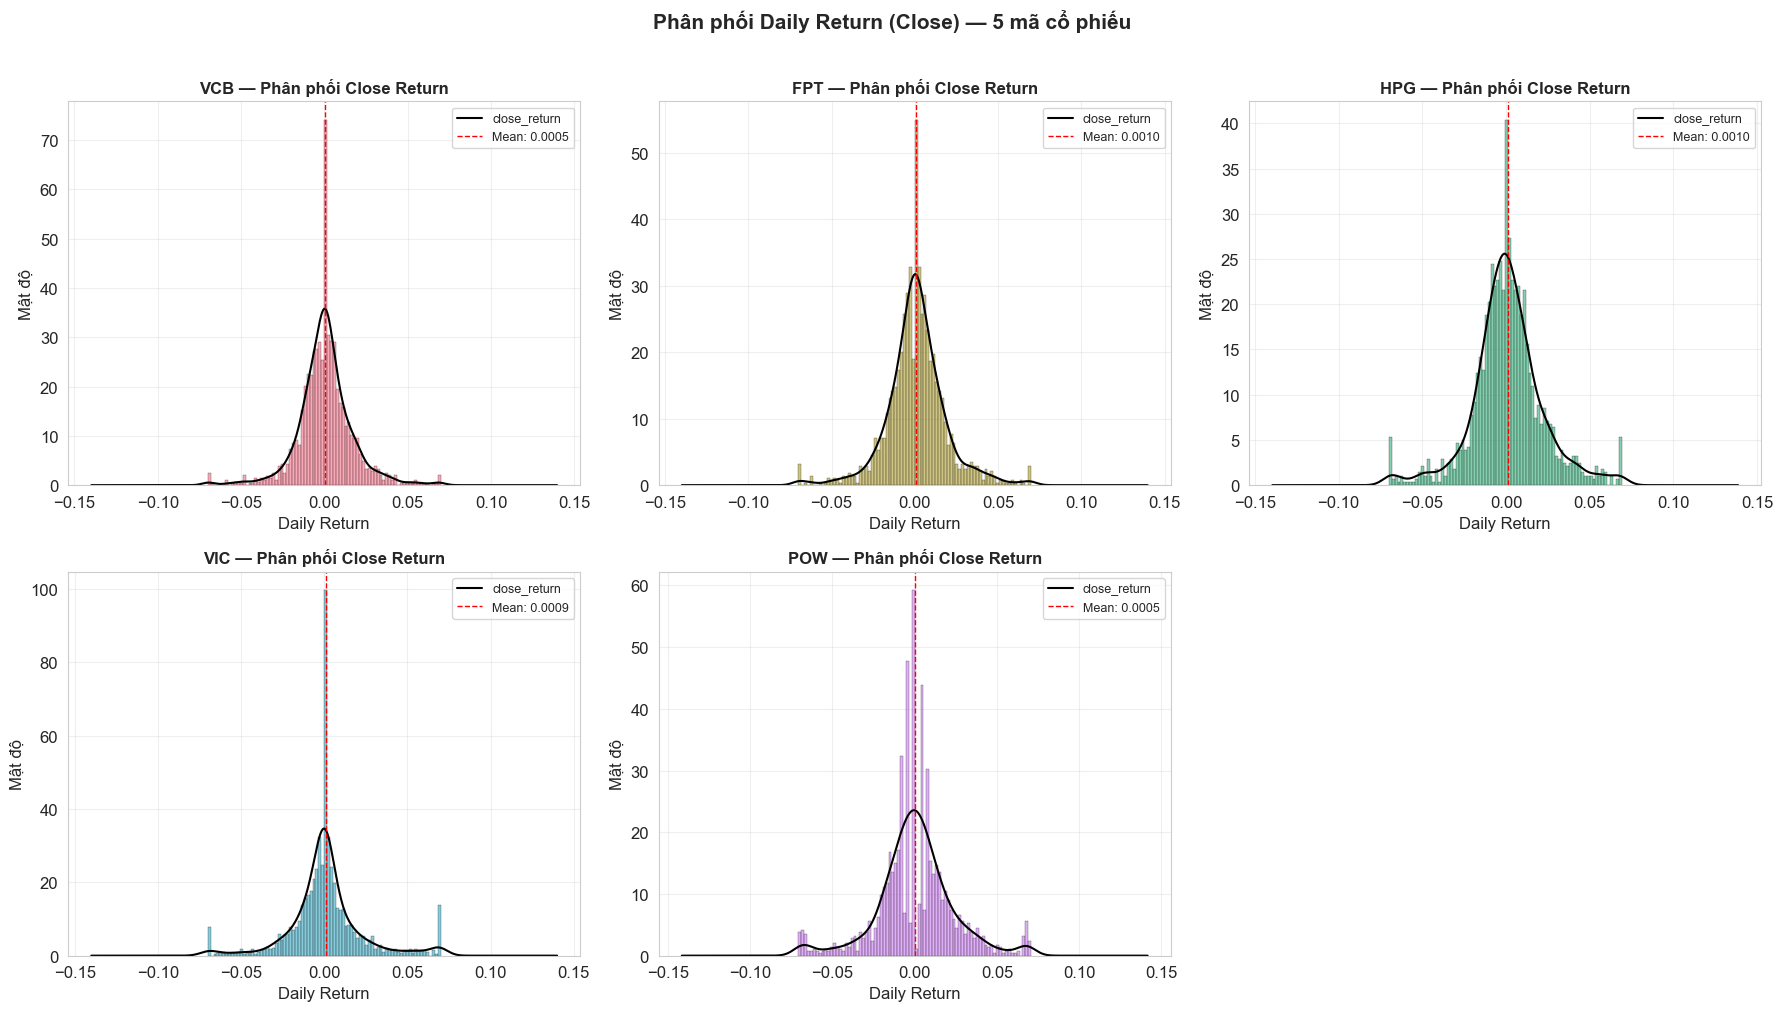

In [6]:
# Trực quan hóa phân phối daily return (close_return) của 5 mã
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, symbol in enumerate(STOCK_SYMBOLS):
    if symbol in returns_data:
        df = returns_data[symbol]
        ax = axes[idx]
        
        # Histogram + KDE
        ax.hist(df['close_return'].dropna(), bins=80, density=True, 
                alpha=0.6, color=sns.color_palette('husl', 5)[idx], edgecolor='black', linewidth=0.3)
        df['close_return'].dropna().plot.kde(ax=ax, color='black', linewidth=1.5)
        
        # Thống kê
        mean_ret = df['close_return'].mean()
        std_ret = df['close_return'].std()
        ax.axvline(mean_ret, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean_ret:.4f}')
        ax.set_title(f'{symbol} — Phân phối Close Return', fontsize=12, fontweight='bold')
        ax.set_xlabel('Daily Return')
        ax.set_ylabel('Mật độ')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

for idx in range(len(STOCK_SYMBOLS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Phân phối Daily Return (Close) — 5 mã cổ phiếu', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2.5. Chia dữ liệu — Train / Test (theo thời gian)

**QUAN TRỌNG**: Với dữ liệu chuỗi thời gian, **KHÔNG ĐƯỢC dùng `train_test_split` ngẫu nhiên** vì sẽ gây **data leakage nghiêm trọng** — mô hình "nhìn thấy" dữ liệu tương lai trong quá trình huấn luyện.

**Cách chia đúng:**
- Chia theo thứ tự thời gian: dữ liệu cũ → train, dữ liệu mới → test
- **Train**: 01/01/2020 → 31/12/2024 (~80%)
- **Test**: 01/01/2025 → hiện tại (~20%)
- `shuffle=False` để giữ nguyên thứ tự thời gian

> **Lưu ý**: Ở Bước 5, ta sẽ dùng `TimeSeriesSplit` cho cross-validation trong quá trình huấn luyện, nhưng ở đây ta cần một tập test cuối cùng hoàn toàn tách biệt.

In [7]:
# Chia dữ liệu theo thời gian: Train (2020-2024) / Test (2025+)
SPLIT_DATE = '2025-01-01'
splits = {}

for symbol, df in returns_data.items():
    # Loại bỏ NaN (nếu còn sót)
    df_clean = df.dropna().reset_index(drop=True)
    
    # Chia theo mốc thời gian
    train_df = df_clean[df_clean['time'] < SPLIT_DATE].reset_index(drop=True)
    test_df = df_clean[df_clean['time'] >= SPLIT_DATE].reset_index(drop=True)
    
    splits[symbol] = {
        'train': train_df,
        'test': test_df
    }
    
    total = len(df_clean)
    print(f"\n{symbol}:")
    print(f"  Tổng: {total} phiên")
    print(f"  Train: {len(train_df)} phiên ({len(train_df)/total*100:.1f}%) | {train_df['time'].min().date()} → {train_df['time'].max().date()}")
    print(f"  Test:  {len(test_df)} phiên ({len(test_df)/total*100:.1f}%) | {test_df['time'].min().date()} → {test_df['time'].max().date()}")

print(f"\n→ Mốc chia: {SPLIT_DATE}")
print(f"→ Train = dữ liệu trước {SPLIT_DATE}, Test = dữ liệu từ {SPLIT_DATE} trở đi")


VCB:
  Tổng: 1622 phiên
  Train: 1325 phiên (81.7%) | 2019-09-18 → 2024-12-31
  Test:  297 phiên (18.3%) | 2025-01-02 → 2026-03-18

FPT:
  Tổng: 1622 phiên
  Train: 1325 phiên (81.7%) | 2019-09-18 → 2024-12-31
  Test:  297 phiên (18.3%) | 2025-01-02 → 2026-03-18

HPG:
  Tổng: 1622 phiên
  Train: 1325 phiên (81.7%) | 2019-09-18 → 2024-12-31
  Test:  297 phiên (18.3%) | 2025-01-02 → 2026-03-18

VIC:
  Tổng: 1622 phiên
  Train: 1325 phiên (81.7%) | 2019-09-18 → 2024-12-31
  Test:  297 phiên (18.3%) | 2025-01-02 → 2026-03-18

POW:
  Tổng: 1622 phiên
  Train: 1325 phiên (81.7%) | 2019-09-18 → 2024-12-31
  Test:  297 phiên (18.3%) | 2025-01-02 → 2026-03-18

VNINDEX:
  Tổng: 1622 phiên
  Train: 1325 phiên (81.7%) | 2019-09-18 → 2024-12-31
  Test:  297 phiên (18.3%) | 2025-01-02 → 2026-03-18

USDVND:
  Tổng: 1614 phiên
  Train: 1304 phiên (80.8%) | 2020-01-02 → 2024-12-31
  Test:  310 phiên (19.2%) | 2025-01-02 → 2026-03-17

→ Mốc chia: 2025-01-01
→ Train = dữ liệu trước 2025-01-01, Test = dữ

## 2.6. Chuẩn hóa dữ liệu (Scaling) — MinMaxScaler

Áp dụng **MinMaxScaler** để đưa dữ liệu về cùng khoảng [0, 1]:

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

### Quy trình chống Data Leakage:
1. **Fit** scaler **CHỈ trên tập train** → học được min/max từ dữ liệu quá khứ
2. **Transform** tập train bằng scaler đã fit
3. **Transform** tập test bằng **cùng scaler** (KHÔNG fit lại!)

> Nếu fit scaler trên toàn bộ dữ liệu → scaler "biết" min/max của tương lai → data leakage!

In [8]:
# Áp dụng MinMaxScaler — Fit trên train, Transform trên test
scaled_data = {}

for symbol, split_dict in splits.items():
    train_df = split_dict['train'].copy()
    test_df = split_dict['test'].copy()
    
    # Xác định cột feature (loại bỏ cột time)
    feature_cols = [col for col in train_df.columns if col != 'time']
    
    # Khởi tạo MinMaxScaler
    scaler = MinMaxScaler()
    
    # FIT scaler chỉ trên tập TRAIN
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    
    # TRANSFORM tập TEST bằng scaler đã fit (KHÔNG fit lại!)
    test_df[feature_cols] = scaler.transform(test_df[feature_cols])
    
    scaled_data[symbol] = {
        'train': train_df,
        'test': test_df,
        'scaler': scaler,
        'feature_columns': feature_cols
    }
    
    print(f"\n{'='*60}")
    print(f"{symbol} — Chuẩn hóa MinMaxScaler")
    print(f"{'='*60}")
    print(f"Feature columns: {feature_cols}")
    print(f"\nTrain (sau scaling) — min/max:")
    print(f"  Min: {train_df[feature_cols].min().min():.4f}")
    print(f"  Max: {train_df[feature_cols].max().max():.4f}")
    print(f"\nTest (sau scaling) — min/max:")
    print(f"  Min: {test_df[feature_cols].min().min():.4f}")
    print(f"  Max: {test_df[feature_cols].max().max():.4f}")
    
    # Test có thể vượt ngoài [0,1] vì scaler fit trên train — đây là hành vi đúng!
    if test_df[feature_cols].max().max() > 1.0 or test_df[feature_cols].min().min() < 0.0:
        print(f"  ℹ Test có giá trị ngoài [0,1] — đúng vì scaler fit trên train, không phải data leakage")

print(f"\n→ Đã chuẩn hóa {len(scaled_data)} bộ dữ liệu")


VCB — Chuẩn hóa MinMaxScaler
Feature columns: ['open_return', 'high_return', 'low_return', 'close_return', 'volume']

Train (sau scaling) — min/max:
  Min: 0.0000
  Max: 1.0000

Test (sau scaling) — min/max:
  Min: -0.0120
  Max: 5.3204
  ℹ Test có giá trị ngoài [0,1] — đúng vì scaler fit trên train, không phải data leakage

FPT — Chuẩn hóa MinMaxScaler
Feature columns: ['open_return', 'high_return', 'low_return', 'close_return', 'volume']

Train (sau scaling) — min/max:
  Min: 0.0000
  Max: 1.0000

Test (sau scaling) — min/max:
  Min: -0.1333
  Max: 3.5189
  ℹ Test có giá trị ngoài [0,1] — đúng vì scaler fit trên train, không phải data leakage

HPG — Chuẩn hóa MinMaxScaler
Feature columns: ['open_return', 'high_return', 'low_return', 'close_return', 'volume']

Train (sau scaling) — min/max:
  Min: 0.0000
  Max: 1.0000

Test (sau scaling) — min/max:
  Min: -0.0045
  Max: 2.1906
  ℹ Test có giá trị ngoài [0,1] — đúng vì scaler fit trên train, không phải data leakage

VIC — Chuẩn hóa Mi

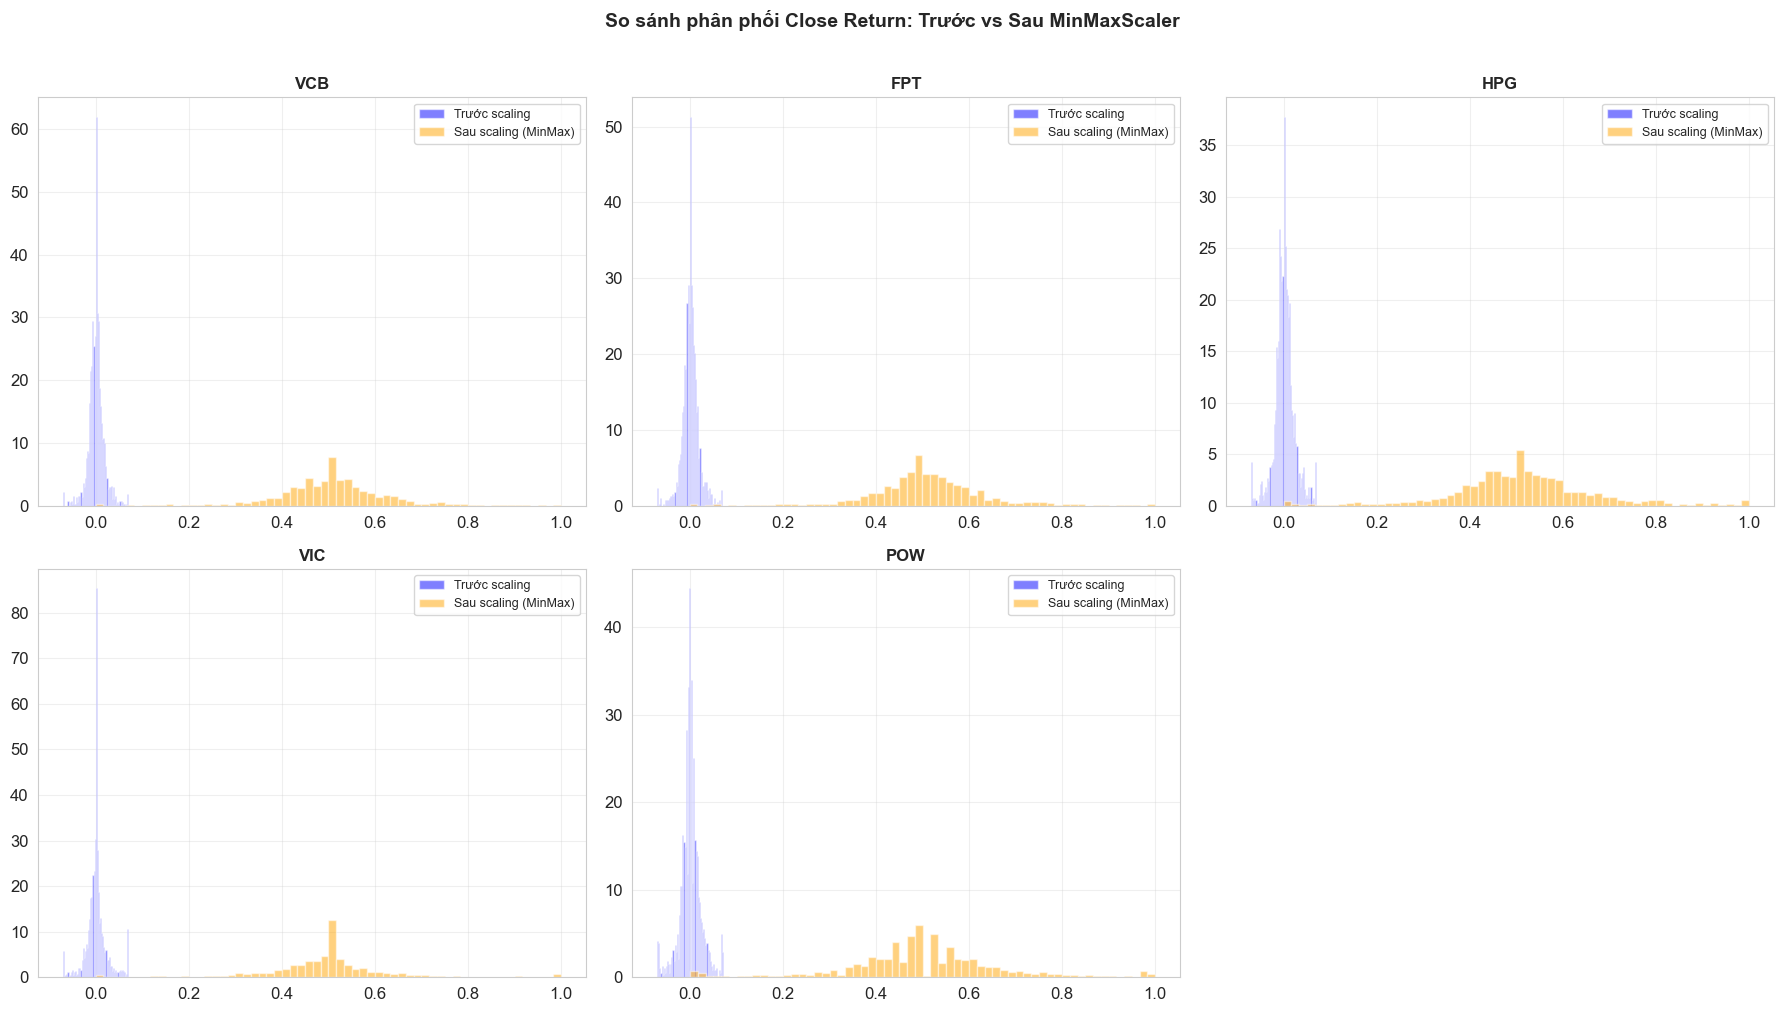

In [9]:
# Trực quan hóa: So sánh trước và sau scaling cho close_return
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, symbol in enumerate(STOCK_SYMBOLS):
    if symbol in scaled_data:
        ax = axes[idx]
        
        # Trước scaling (từ returns_data)
        before = returns_data[symbol]['close_return'].dropna()
        # Sau scaling (từ scaled_data train)
        after = scaled_data[symbol]['train']['close_return'].dropna()
        
        ax.hist(before, bins=60, alpha=0.5, label='Trước scaling', color='blue', density=True)
        ax.hist(after, bins=60, alpha=0.5, label='Sau scaling (MinMax)', color='orange', density=True)
        ax.set_title(f'{symbol}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

for idx in range(len(STOCK_SYMBOLS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('So sánh phân phối Close Return: Trước vs Sau MinMaxScaler', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2.7. Lưu dữ liệu đã xử lý

Lưu các file sau cho từng mã cổ phiếu:
- `{symbol}_train_scaled.csv` — Tập train đã chuẩn hóa
- `{symbol}_test_scaled.csv` — Tập test đã chuẩn hóa
- `{symbol}_scaler.pkl` — Scaler object (để inverse transform khi cần)
- `{symbol}_train_raw.csv` — Tập train chưa chuẩn hóa (giữ daily return gốc)
- `{symbol}_test_raw.csv` — Tập test chưa chuẩn hóa

In [10]:
# Lưu dữ liệu đã xử lý
print("=" * 80)
print("LƯU DỮ LIỆU ĐÃ TIỀN XỬ LÝ")
print("=" * 80)

for symbol in scaled_data:
    # Tạo thư mục riêng cho từng mã
    stock_dir = os.path.join(PROCESSED_DIR, 'scaled', symbol)
    os.makedirs(stock_dir, exist_ok=True)
    
    data = scaled_data[symbol]
    
    # Lưu tập train/test đã scaling
    train_path = os.path.join(stock_dir, f'{symbol}_train_scaled.csv')
    test_path = os.path.join(stock_dir, f'{symbol}_test_scaled.csv')
    data['train'].to_csv(train_path, index=False)
    data['test'].to_csv(test_path, index=False)
    
    # Lưu scaler object (pickle) để dùng cho inference sau này
    scaler_path = os.path.join(stock_dir, f'{symbol}_scaler.pkl')
    with open(scaler_path, 'wb') as f:
        pickle.dump(data['scaler'], f)
    
    # Lưu tập train/test chưa scaling (daily return gốc)
    raw_dir = os.path.join(PROCESSED_DIR, 'returns', symbol)
    os.makedirs(raw_dir, exist_ok=True)
    splits[symbol]['train'].to_csv(os.path.join(raw_dir, f'{symbol}_train_raw.csv'), index=False)
    splits[symbol]['test'].to_csv(os.path.join(raw_dir, f'{symbol}_test_raw.csv'), index=False)
    
    print(f"\n{symbol}:")
    print(f"  ✓ Train scaled: {train_path} ({len(data['train'])} dòng)")
    print(f"  ✓ Test scaled:  {test_path} ({len(data['test'])} dòng)")
    print(f"  ✓ Scaler:       {scaler_path}")
    print(f"  ✓ Train raw:    {raw_dir}/{symbol}_train_raw.csv")
    print(f"  ✓ Test raw:     {raw_dir}/{symbol}_test_raw.csv")

print(f"\n{'='*80}")
print("✓ HOÀN TẤT LƯU DỮ LIỆU TIỀN XỬ LÝ!")
print(f"{'='*80}")

LƯU DỮ LIỆU ĐÃ TIỀN XỬ LÝ

VCB:
  ✓ Train scaled: ..\data\processed\scaled\VCB\VCB_train_scaled.csv (1325 dòng)
  ✓ Test scaled:  ..\data\processed\scaled\VCB\VCB_test_scaled.csv (297 dòng)
  ✓ Scaler:       ..\data\processed\scaled\VCB\VCB_scaler.pkl
  ✓ Train raw:    ..\data\processed\returns\VCB/VCB_train_raw.csv
  ✓ Test raw:     ..\data\processed\returns\VCB/VCB_test_raw.csv

FPT:
  ✓ Train scaled: ..\data\processed\scaled\FPT\FPT_train_scaled.csv (1325 dòng)
  ✓ Test scaled:  ..\data\processed\scaled\FPT\FPT_test_scaled.csv (297 dòng)
  ✓ Scaler:       ..\data\processed\scaled\FPT\FPT_scaler.pkl
  ✓ Train raw:    ..\data\processed\returns\FPT/FPT_train_raw.csv
  ✓ Test raw:     ..\data\processed\returns\FPT/FPT_test_raw.csv

HPG:
  ✓ Train scaled: ..\data\processed\scaled\HPG\HPG_train_scaled.csv (1325 dòng)
  ✓ Test scaled:  ..\data\processed\scaled\HPG\HPG_test_scaled.csv (297 dòng)
  ✓ Scaler:       ..\data\processed\scaled\HPG\HPG_scaler.pkl
  ✓ Train raw:    ..\data\processe

## 2.8. Kiểm chứng: Không có Data Leakage

Xác nhận rằng quy trình tiền xử lý không gây data leakage.

In [11]:
# Kiểm chứng data leakage
print("=" * 70)
print("KIỂM CHỨNG KHÔNG CÓ DATA LEAKAGE")
print("=" * 70)

leakage_found = False

for symbol in STOCK_SYMBOLS:
    if symbol in scaled_data:
        train = scaled_data[symbol]['train']
        test = scaled_data[symbol]['test']
        
        # 1. Kiểm tra thời gian: train phải trước test
        train_max_date = train['time'].max()
        test_min_date = test['time'].min()
        time_ok = train_max_date < test_min_date
        
        # 2. Kiểm tra không có overlap dữ liệu
        overlap = pd.merge(train[['time']], test[['time']], on='time', how='inner')
        overlap_ok = len(overlap) == 0
        
        status = "✓" if (time_ok and overlap_ok) else "✗"
        if not (time_ok and overlap_ok):
            leakage_found = True
        
        print(f"\n{status} {symbol}:")
        print(f"  Train: ... → {train_max_date.date()}")
        print(f"  Test:  {test_min_date.date()} → ...")
        print(f"  Thời gian train < test: {'Đúng' if time_ok else 'SAI!'}")
        print(f"  Overlap: {len(overlap)} dòng {'(OK)' if overlap_ok else '(LEAKAGE!)'}")
        print(f"  Scaler fit trên train only: Đúng (MinMaxScaler fit_transform trên train)")

if not leakage_found:
    print(f"\n{'='*70}")
    print("✓ KHÔNG CÓ DATA LEAKAGE — Quy trình tiền xử lý an toàn!")
    print(f"{'='*70}")
else:
    print(f"\n{'='*70}")
    print("⚠ PHÁT HIỆN DATA LEAKAGE — Cần kiểm tra lại!")
    print(f"{'='*70}")

KIỂM CHỨNG KHÔNG CÓ DATA LEAKAGE

✓ VCB:
  Train: ... → 2024-12-31
  Test:  2025-01-02 → ...
  Thời gian train < test: Đúng
  Overlap: 0 dòng (OK)
  Scaler fit trên train only: Đúng (MinMaxScaler fit_transform trên train)

✓ FPT:
  Train: ... → 2024-12-31
  Test:  2025-01-02 → ...
  Thời gian train < test: Đúng
  Overlap: 0 dòng (OK)
  Scaler fit trên train only: Đúng (MinMaxScaler fit_transform trên train)

✓ HPG:
  Train: ... → 2024-12-31
  Test:  2025-01-02 → ...
  Thời gian train < test: Đúng
  Overlap: 0 dòng (OK)
  Scaler fit trên train only: Đúng (MinMaxScaler fit_transform trên train)

✓ VIC:
  Train: ... → 2024-12-31
  Test:  2025-01-02 → ...
  Thời gian train < test: Đúng
  Overlap: 0 dòng (OK)
  Scaler fit trên train only: Đúng (MinMaxScaler fit_transform trên train)

✓ POW:
  Train: ... → 2024-12-31
  Test:  2025-01-02 → ...
  Thời gian train < test: Đúng
  Overlap: 0 dòng (OK)
  Scaler fit trên train only: Đúng (MinMaxScaler fit_transform trên train)

✓ KHÔNG CÓ DATA LEAKA

## Tổng kết Bước 2

### Kết quả đạt được:
1. **Xử lý Missing Values**: Forward Fill + Backward Fill → 0 null còn lại
2. **Daily Return**: Chuyển giá tuyệt đối → % thay đổi hàng ngày (stationary)
3. **Chia dữ liệu**: Train (2020–2024) / Test (2025+) theo thứ tự thời gian, KHÔNG shuffle
4. **MinMaxScaler**: Fit chỉ trên train → transform trên test → **không data leakage**
5. **Lưu dữ liệu**: CSV + scaler pickle cho 7 bộ dữ liệu (5 CP + VN-Index + USD/VND)

### Các biện pháp chống Data Leakage:
- ✓ Chia dữ liệu TRƯỚC khi scaling
- ✓ Scaler fit chỉ trên tập train
- ✓ Không shuffle dữ liệu chuỗi thời gian
- ✓ Train/Test không overlap về thời gian

### Cấu trúc thư mục output:
```
data/processed/
├── scaled/{symbol}/          # Dữ liệu đã chuẩn hóa
│   ├── {symbol}_train_scaled.csv
│   ├── {symbol}_test_scaled.csv
│   └── {symbol}_scaler.pkl
└── returns/{symbol}/         # Daily return gốc (chưa scale)
    ├── {symbol}_train_raw.csv
    └── {symbol}_test_raw.csv
```

### Bước tiếp theo:
→ **Bước 3: Kỹ Thuật Đặc Trưng (Feature Engineering)** — Tạo các chỉ báo kỹ thuật, lag features, volatility, và biến mục tiêu